# Super brief overview of pipeline

Here I very briefly review parts of the pipeline that are relevant for the inception loop experiment. In general, the [pipeline is well packaged](https://github.com/cajal/pipeline) and requires little to no active intervention during the closed loop experiment. However, there are a few tables you would benefit from being familar with.

## Components of Pipeline

Pipeline consists of multiple **schemas**, allowing us to organize related tables together. Below, we create DataJoint *virtual modules* to gain access to these schemas without pulling the source code from the repository.

In [21]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt

In [36]:
experiment = dj.create_virtual_module('experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('meso', 'pipeline_meso')
reso = dj.create_virtual_module('reso', 'pipeline_reso')

anatomy = dj.create_virtual_module('anatomy', 'pipeline_anatomy')
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')

### Experiment

As the name suggests, it contains tables pertaining to each experiment as a whole, such as session, rig, lens, FOV as well as MonitorCalibration. Information contained in these tables are frequently used by downstream tables to make adjustments to the stimulus.

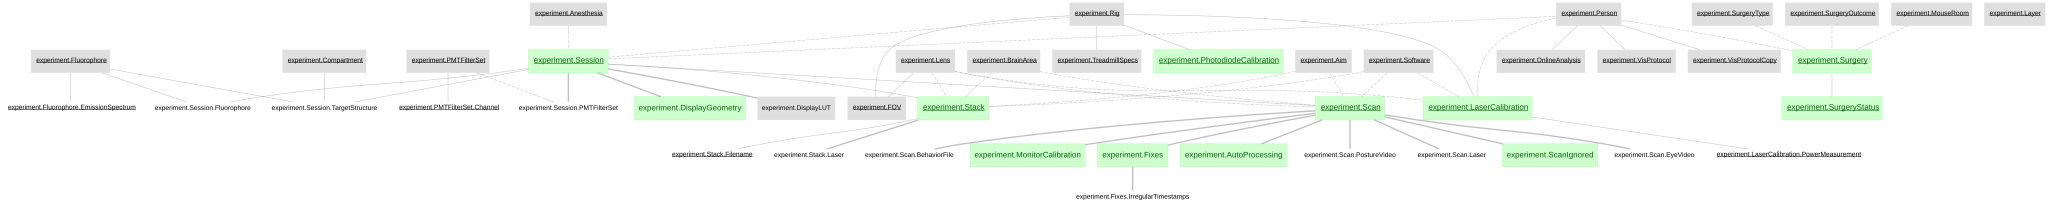

In [6]:
dj.ERD(experiment)

MonitorCalibration provides monitor luminance-gamma correction information. This is used during the closed loop stimulus generation to ensure that stimulus parameters such as contrast is matched in the luminance.

In [10]:
experiment.MonitorCalibration()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pixel_value control pixel value (0-255),luminance luminance in cd/m^2,amplitude lum = Amp*pixel_value^gamma + offset,gamma,offset,mse,ts timestamp
0,852,1,=BLOB=,=BLOB=,0.000594,2.08008,0.081413,0.088526,2018-01-22 22:49:13
0,853,1,=BLOB=,=BLOB=,0.000581,2.08392,0.091999,0.089324,2018-01-22 23:56:14
0,854,1,=BLOB=,=BLOB=,0.000588,2.08203,0.064837,0.089021,2018-01-23 00:32:47
0,864,1,=BLOB=,=BLOB=,0.000612,2.07622,0.057063,0.089333,2018-01-23 11:29:31
0,868,1,=BLOB=,=BLOB=,0.000415,2.14578,28.8639,0.068776,2018-01-23 11:55:49
0,869,1,=BLOB=,=BLOB=,0.000406,2.14952,29.9188,0.068399,2018-01-23 12:11:09
0,875,1,=BLOB=,=BLOB=,0.002033,1.82193,-0.737405,0.095195,2018-01-24 21:00:29
0,884,6,=BLOB=,=BLOB=,0.000616,2.07929,0.981903,0.093943,2018-01-26 21:57:17
0,885,1,=BLOB=,=BLOB=,0.000621,2.07737,0.984537,0.094206,2018-01-26 22:03:31
0,886,1,=BLOB=,=BLOB=,0.000631,2.07441,0.979776,0.093178,2018-01-26 22:55:32


### Meso

This is where the actual pre-processing for mesoscope data occurs.

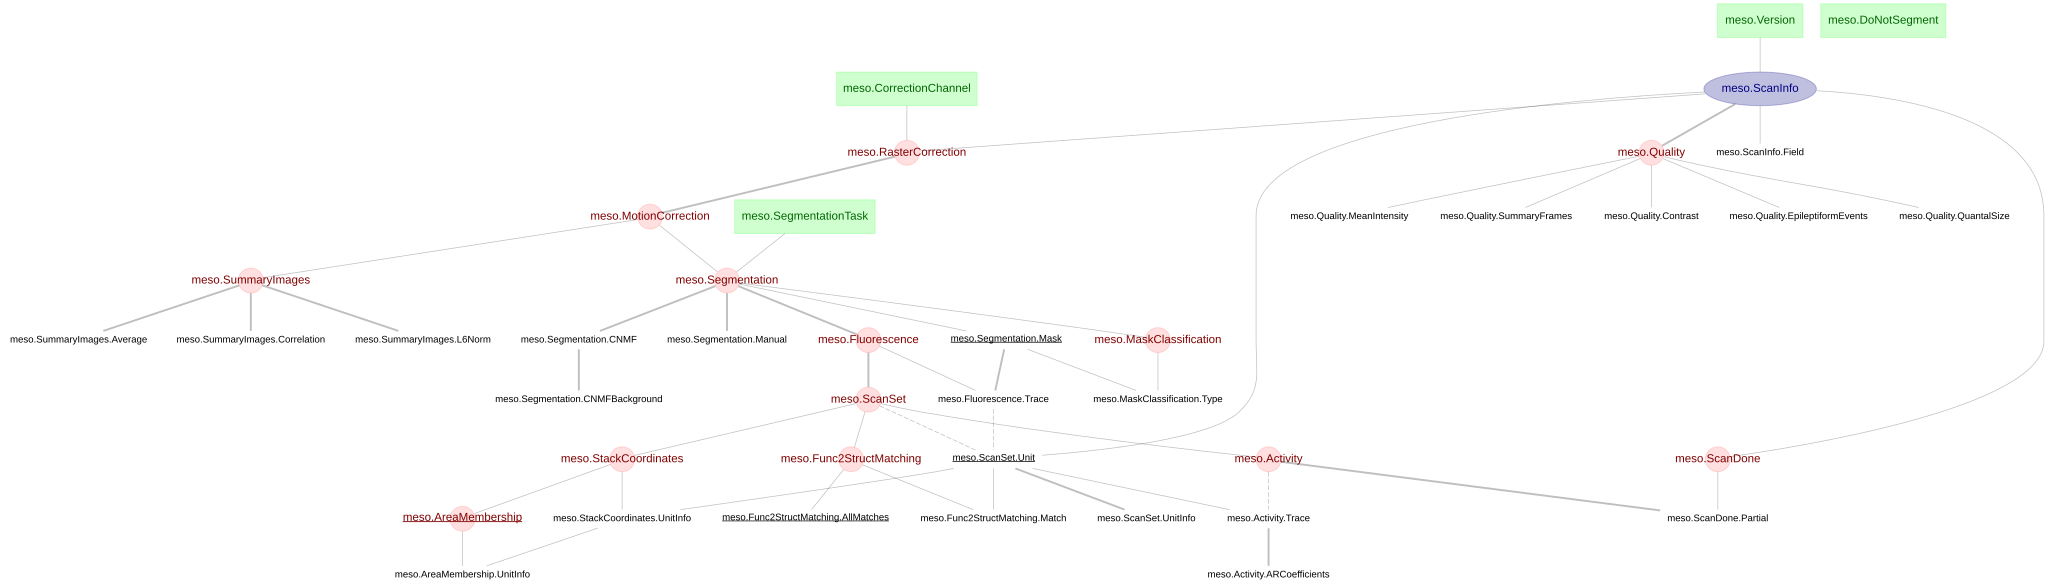

In [11]:
dj.ERD(meso)

Among tables here, `meso.ScanSet.Unit` and `meso.Activity.Trace` provides the segmented unit and their traces.

In [19]:
meso.ScanSet.Unit()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,unit_id unique per scan & segmentation method,field,channel,mask_id
11521,2,1,1,3,1,1,1,1
11521,2,1,1,3,2,1,1,2
11521,2,1,1,3,3,1,1,3
11521,2,1,1,3,4,1,1,4
11521,2,1,1,3,5,1,1,5
11521,2,1,1,3,6,1,1,6
11521,2,1,1,3,7,1,1,7
11521,2,1,1,3,8,1,1,8
11521,2,1,1,3,9,1,1,9
11521,2,1,1,3,10,1,1,10


In [20]:
meso.Activity.Trace()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,unit_id unique per scan & segmentation method,spike_method spike inference method,field,channel,trace
11521,2,1,1,3,1,2,1,1,=BLOB=
11521,2,1,1,3,2,2,1,1,=BLOB=
11521,2,1,1,3,3,2,1,1,=BLOB=
11521,2,1,1,3,4,2,1,1,=BLOB=
11521,2,1,1,3,5,2,1,1,=BLOB=
11521,2,1,1,3,6,2,1,1,=BLOB=
11521,2,1,1,3,7,2,1,1,=BLOB=
11521,2,1,1,3,8,2,1,1,=BLOB=
11521,2,1,1,3,9,2,1,1,=BLOB=
11521,2,1,1,3,10,2,1,1,=BLOB=


Text(0, 0.5, 'Activity (a.u.)')

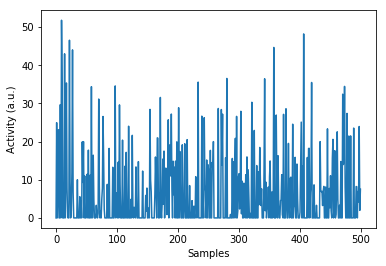

In [25]:
trace = meso.Activity.Trace().fetch('trace', limit=1)[0]
plt.plot(trace[:500])
plt.xlabel('Samples')
plt.ylabel('Activity (a.u.)')

### Anatomy

This contains anatomical information such as Area and Layer membership of units recorded. The filling of mumbership tables is **not** currently automated in the pipeline and must be done semi-manually.

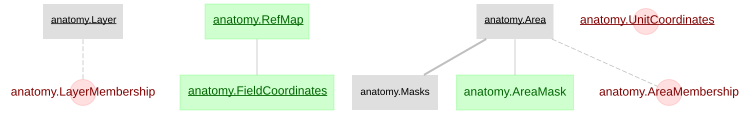

In [28]:
dj.ERD(anatomy)

In [26]:
anatomy.AreaMembership()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,unit_id,brain_area short name for cortical area
9254,1,2,1,3,127,AL
9254,1,2,1,3,128,AL
9254,1,2,1,3,131,AL
9254,1,2,1,3,142,AL
9254,1,2,1,3,143,AL
9254,1,2,1,3,144,AL
9254,1,2,1,3,145,AL
9254,1,2,1,3,146,AL
9254,1,2,1,3,147,AL
9254,1,2,1,3,148,AL


In [27]:
anatomy.LayerMembership()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,unit_id unique per scan & segmentation method,layer short name for cortical area
15685,2,11,1,3,1,L1
15685,2,11,1,3,2,L1
15685,2,11,1,3,3,L1
15685,2,11,1,3,4,L1
15685,2,11,1,3,5,L1
15685,2,11,1,3,6,L1
15685,2,11,1,3,7,L1
15685,2,11,1,3,8,L1
15685,2,11,1,3,9,L1
15685,2,11,1,3,10,L1


### Fuse

As the name suggests, this schemas "fuses" `meso` and `reso` branches of pipelines so that anything downstream of this can work on units and activity traces obtained through either kind of microscope uniformly.

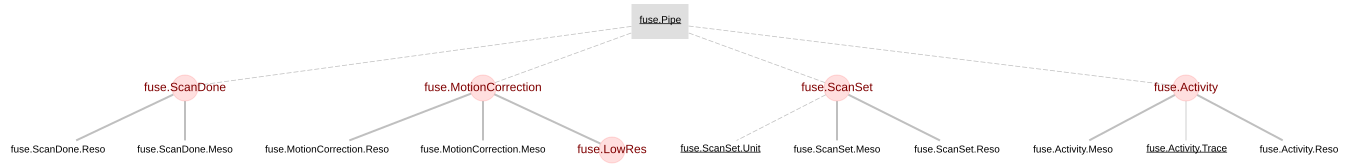

In [32]:
dj.ERD(fuse)

In particular, the important tables are `fuse.ScanDone` which are filled with Scans that are fully processed through the pipeline and `fuse.Activity.Trace` which acts as a common access point for activity traces of units regardless of the source.

In [35]:
fuse.ScanDone()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,pipe pipeline name
11521,2,1,1,3,2,meso
11521,2,1,1,3,3,meso
11521,2,1,1,3,5,meso
11521,2,2,1,3,2,meso
11521,2,2,1,3,3,meso
11521,2,2,1,3,5,meso
11521,2,3,1,3,2,meso
11521,2,3,1,3,3,meso
11521,2,3,1,3,5,meso
11521,2,4,1,3,2,meso


In [33]:
fuse.Activity.Trace()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,field,channel,segmentation_method,spike_method spike inference method,unit_id unique per scan & segmentation method
0,1137,2,1,1,1,3,5,1
0,1137,2,1,1,1,3,5,2
0,1137,2,1,1,1,3,5,3
0,1137,2,1,1,1,3,5,4
0,1137,2,1,1,1,3,5,5
0,1137,2,1,1,1,3,5,6
0,1137,2,1,1,1,3,5,7
0,1137,2,1,1,1,3,5,8
0,1137,2,1,1,1,3,5,9
0,1137,2,1,1,1,3,5,10


## Summary

Here we took a very brief look at the pipeline. Obviously, there are far more to the pipeline than what we covered here , but the set of tables mentioned here serve as a good starting point for understanding downstream tables involved in an inception loop experiment.